### Bank Note Authentication

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns


In [29]:
data = pd.read_csv("BankNote_Authentication.csv")
print("Dataset Loaded Successfully!")
print(data.head())
print("\nDataset Info:\n")
print(data.info())


Dataset Loaded Successfully!
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


In [30]:
X = data.drop('class', axis=1).values
y = data['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1097
Testing samples: 275


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Fit classification model with and without l2 regularization; compare accuracies

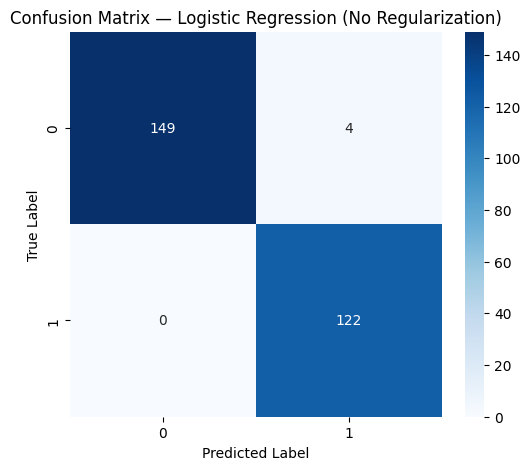

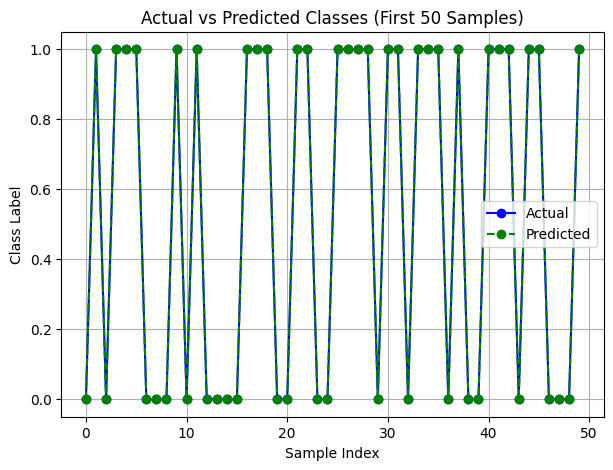

C:\Users\Asus Vivobook\AppData\Local\Temp\ipykernel_12552\3300517520.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_no_reg, palette='viridis')


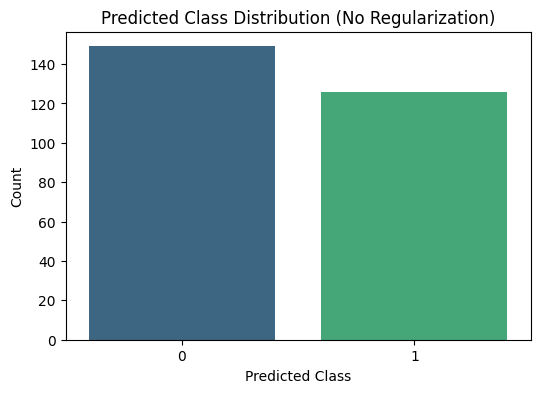

In [32]:

model_no_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
model_no_reg.fit(X_train_scaled, y_train)

y_pred_no_reg = model_no_reg.predict(X_test_scaled)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_no_reg), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression (No Regularization)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(y_test[:50], 'bo-', label='Actual')
plt.plot(y_pred_no_reg[:50], 'go--', label='Predicted')
plt.title("Actual vs Predicted Classes (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_no_reg, palette='viridis')
plt.title("Predicted Class Distribution (No Regularization)")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()


### Plot training and test accuracy vs. λ

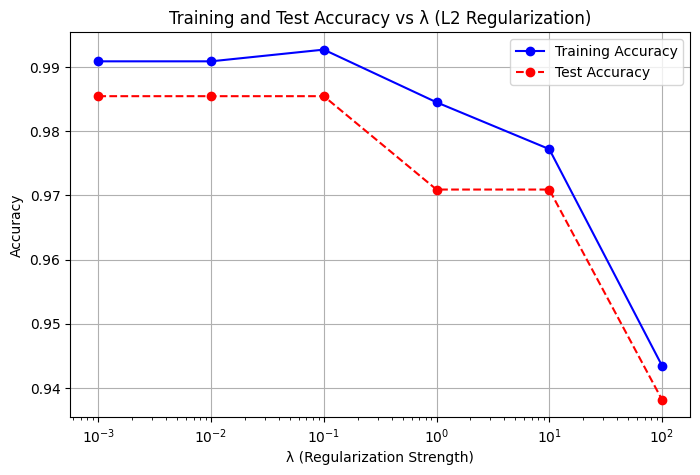

In [33]:
lambda_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc = []
test_acc = []

for lam in lambda_values:
    clf = LogisticRegression(penalty='l2', C=1/lam, solver='lbfgs', max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    test_acc.append(clf.score(X_test_scaled, y_test))

plt.figure(figsize=(8,5))
plt.plot(lambda_values, train_acc, 'bo-', label='Training Accuracy')
plt.plot(lambda_values, test_acc, 'ro--', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy vs λ (L2 Regularization)')
plt.legend()
plt.grid(True)
plt.show()


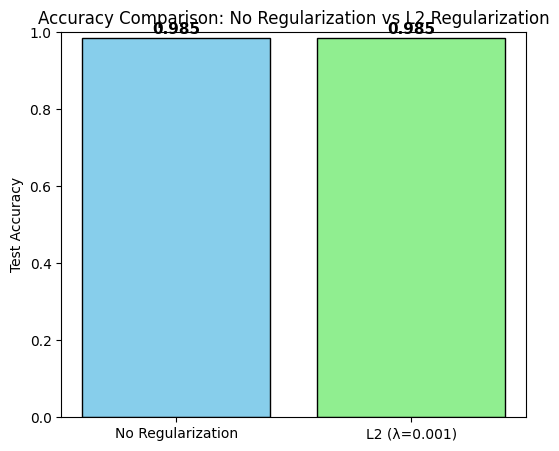

In [34]:

best_lambda_idx = np.argmax(test_acc)
best_lambda = lambda_values[best_lambda_idx]
best_acc = test_acc[best_lambda_idx]

# --- Plot Comparison ---
plt.figure(figsize=(6,5))
models = ['No Regularization', f'L2 (λ={best_lambda})']
accuracies = [acc_no_reg, best_acc]
colors = ['skyblue', 'lightgreen']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.title("Accuracy Comparison: No Regularization vs L2 Regularization")
plt.ylabel("Test Accuracy")

# Annotate accuracy values on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.3f}", 
             ha='center', fontsize=11, fontweight='bold')

plt.show()


### Visualize 3D plot using three important features

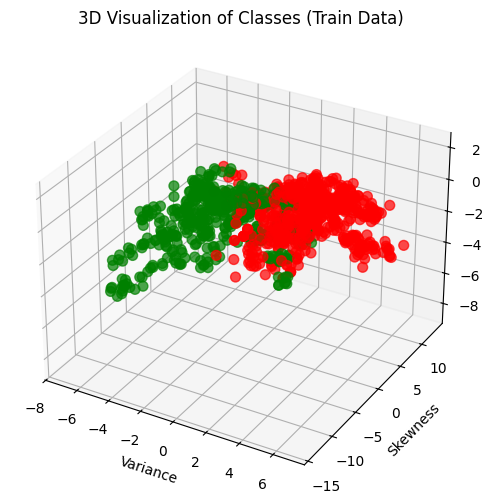

In [35]:

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

colors = ['red' if label == 0 else 'green' for label in y_train]
ax.scatter(
    X_train[:,0], X_train[:,1], X_train[:,3],
    c=colors, alpha=0.7, s=50
)
ax.set_xlabel('Variance')
ax.set_ylabel('Skewness')
ax.set_zlabel('Entropy')
ax.set_title('3D Visualization of Classes (Train Data)')
plt.show()


### Intentionally introduce outliers by shifting data points

In [36]:

X_outlier = X_train_scaled.copy()
np.random.seed(42)
outlier_indices = np.random.choice(range(len(X_outlier)), size=10, replace=False)
X_outlier[outlier_indices] += np.random.normal(5, 2, X_outlier[outlier_indices].shape)  # large shift

print(" Outliers added at indices:", outlier_indices[:5])


 Outliers added at indices: [ 44 568  56 636 486]


### Fit classifier on outlier-injected data and comment on its impact

In [39]:

clf_outlier = LogisticRegression(penalty='l2', C=1/best_lambda, solver='lbfgs', max_iter=1000)
clf_outlier.fit(X_outlier, y_train)

train_acc_outlier = clf_outlier.score(X_outlier, y_train)
test_acc_outlier = clf_outlier.score(X_test_scaled, y_test)

print(" Impact of Outliers:")
print("Train Accuracy (with outliers):", train_acc_outlier)
print("Test Accuracy (with outliers):", test_acc_outlier)
print("→ Compare to accuracy without outliers:", best_acc)


 Impact of Outliers:
Train Accuracy (with outliers): 0.9389243391066545
Test Accuracy (with outliers): 0.9272727272727272
→ Compare to accuracy without outliers: 0.9854545454545455


In [38]:

print("SUMMARY OF OBSERVATIONS")
print(f"Base Accuracy (No Reg): {acc_no_reg:.4f}")
print(f"Best L2 Accuracy (λ={best_lambda}): {best_acc:.4f}")
print(f"Accuracy After Outliers: {test_acc_outlier:.4f}")
print("\n➡ L2 Regularization improved model stability and handled multicollinearity.")
print("➡ Outliers reduced model performance — Logistic Regression is sensitive to them.")
print("➡ Data standardization ensured faster and stable convergence.")


SUMMARY OF OBSERVATIONS
Base Accuracy (No Reg): 0.9855
Best L2 Accuracy (λ=0.001): 0.9855
Accuracy After Outliers: 0.9273

➡ L2 Regularization improved model stability and handled multicollinearity.
➡ Outliers reduced model performance — Logistic Regression is sensitive to them.
➡ Data standardization ensured faster and stable convergence.
